# TEB-Ru Windows Sandbox

This notebook is the local (Windows) analogue of the Colab notebook
[`run_in_collab.ipynb`](https://github.com/mkolennikova/TEB-Ru/blob/main/run_in_collab.ipynb).
It downloads, compiles and runs the TEB-Ru model for a user-defined location using ERA5 forcing.

Nothing is installed from this notebook: both the build toolchain and the Python environment
must be prepared in advance.

Step-by-step pipeline:

- [Set up environment](#set-up-environment)
- [Download model from repository](#download-model-from-repository)
- [Model compilation](#model-compilation)
- [Download atmospheric forcing](#download-atmospheric-forcing)
- [Configure and run simulations](#configure-and-run-simulations)
- [Preview simulation results](#preview-simulation-results)

## Windows prerequisites

| Component | Used by this notebook | How to prepare |
| --- | --- | --- |
| Python kernel | conda environment `Fort` | Select the `Fort (TEB-Ru)` kernel in VS Code before running |
| Python packages | `f90nml`, `cdsapi`, `netCDF4`, `xarray`, `pandas`, `numpy`, `matplotlib`, `plotly`, `tqdm`, `ipykernel` | `conda run -n Fort pip install ...` (see below) |
| Fortran compiler | `gfortran` from MSYS2 | `C:\msys64\ucrt64\bin` |
| Build tool | GNU `make` from MSYS2 | `pacman -S --needed make mingw-w64-ucrt-x86_64-gcc` |
| POSIX shell | `sh.exe` from MSYS2 | `C:\msys64\usr\bin`; added to `PATH` automatically below |
| ERA5 access | `%USERPROFILE%\.cdsapirc` | Created once via `install_utils.init_CDS()` |

One-time preparation of the Python environment (run in the Anaconda Prompt, not in this notebook):

```text
conda run -n Fort pip install f90nml cdsapi netCDF4 xarray pandas numpy matplotlib plotly tqdm ipykernel
conda run -n Fort python -m ipykernel install --user --name fort --display-name "Fort (TEB-Ru)"
```


## Set up environment

The dictionary `opts` below controls the runtime behaviour of the notebook:

- `work_dir`: working directory for the site data (ERA5 forcing, namelists, simulation results).
  It is created automatically and kept outside the model repository.
- `local_repo_dir`: path to an existing local clone of the model. If it is not `None`, that clone is
  used as is (no `git clone`, no `git pull`). Set it to `None` to clone `repo_path` into `work_dir`
  (the Colab-like behaviour).
- `repo_path`: URL of the Git repository to clone when `local_repo_dir` is `None`.
- `reload_repo`: if `True` (and `local_repo_dir` is `None`), the existing clone is removed and cloned again.
- `msys2_dir`: MSYS2 installation root providing `sh.exe`, `make` and `gfortran`.
- `python_exe`: interpreter of the `Fort` environment (used for an early sanity check only).
- `required_modules`: modules that must already be installed - this notebook never installs anything.

**Note:** adjust these options before running the next cells.


In [1]:
opts = {
    # Working directory: <work_dir>\<site_name>\forcing_ERA5, params_*.nml and output_* land here.
    'work_dir': r'D:\TEB_work',

    # Existing local clone of the model. None -> clone 'repo_path' into 'work_dir'.
    'local_repo_dir': r'D:\Work\git\TEB-Ru',
    'repo_path': 'https://github.com/mkolennikova/TEB-Ru',
    'reload_repo': False,   # True: remove the clone and clone it again (only if local_repo_dir is None)

    # MSYS2 root (provides sh.exe, make and gfortran for Windows)
    'msys2_dir': r'C:\msys64',

    # Conda environment created for this repository (select the 'Fort (TEB-Ru)' kernel!)
    'python_exe': r'C:\Users\mvar9\anaconda3\envs\Fort\python.exe',

    # Modules that must be installed in advance; the notebook only checks them.
    'required_modules': ['f90nml', 'cdsapi', 'netCDF4', 'xarray', 'pandas',
                         'numpy', 'matplotlib', 'plotly', 'tqdm', 'IPython'],
}


In [2]:
import os, sys, shutil, glob, time
import subprocess
import importlib
import importlib.util
import platform
import pandas as pd
from pathlib import Path

def import_and_reload (module_name: str):
    """Loads a module by name, or reloads it if already imported."""
    if module_name in sys.modules:
        print(f"Reloading existing module: {module_name}")
        return importlib.reload(sys.modules[module_name])
    else:
        print(f"Loading new module: {module_name}")
        return importlib.import_module(module_name)


### Windows toolchain and working directories

`make` is a native Windows build from MSYS2. The `Makefile` relies on POSIX shell features
(`$(shell mkdir -p $(OBJDIR))`, `rm -rf`, `find`), and `gfortran_args` detects the compiler with
`command -v ifort`. Therefore `C:\msys64\usr\bin` (POSIX tools, including `sh.exe`) is put in front
of `PATH`, and GNU make automatically uses `sh.exe` as its shell.
`C:\msys64\ucrt64\bin` provides `make` and `gfortran`.


In [3]:
# ---- Working directories -------------------------------------------------
WORK_DIR = Path(opts['work_dir']).expanduser()
WORK_DIR.mkdir(parents=True, exist_ok=True)

if opts['local_repo_dir']:
    MODEL_DIR = Path(opts['local_repo_dir']).expanduser().resolve()
else:
    MODEL_NAME = os.path.basename(os.path.normpath(opts['repo_path'].rstrip('/')))
    MODEL_DIR = WORK_DIR / MODEL_NAME

PYTHON_DIR = MODEL_DIR / 'python'

# ---- Make the MSYS2 tools visible to `make` ------------------------------
# GNU make for Windows needs a POSIX shell for the Makefile constructs
# `$(shell mkdir -p $(OBJDIR))`, `rm -rf` and `find`; `gfortran_args` detects the
# compiler with `command -v ifort`. With C:\msys64\usr\bin on PATH make picks up
# sh.exe automatically; C:\msys64\ucrt64\bin provides make and gfortran.
msys2_root = Path(opts['msys2_dir'])
msys2_dirs = [msys2_root / 'usr' / 'bin', msys2_root / 'ucrt64' / 'bin', msys2_root / 'mingw64' / 'bin']
msys2_dirs = [str(d) for d in msys2_dirs if d.is_dir()]
os.environ['PATH'] = os.pathsep.join(msys2_dirs + [os.environ['PATH']])

print(f'Python     : {sys.executable}')
print(f'Platform   : {platform.platform()}')
print(f'WORK_DIR   : {WORK_DIR}')
print(f'MODEL_DIR  : {MODEL_DIR}')

# ---- Check the command-line toolchain ------------------------------------
tool_paths = {tool: shutil.which(tool) for tool in ('git', 'make', 'gfortran', 'sh')}
for tool, tool_path in tool_paths.items():
    print(f'{tool:<9}  : {tool_path if tool_path else "NOT FOUND"}')

missing_tools = [tool for tool, tool_path in tool_paths.items() if tool_path is None]
if missing_tools:
    print('\n❌ Missing tools: ' + ', '.join(missing_tools))
    print('   Install MSYS2 (https://www.msys2.org/) and run in the "MSYS2 UCRT64" shell:')
    print('     pacman -S --needed make mingw-w64-ucrt-x86_64-gcc git')
    print('   Then set opts["msys2_dir"] to your MSYS2 root (default C:\\msys64).')
else:
    for cmd in (['make', '--version'], ['gfortran', '--version']):
        result = subprocess.run(cmd, capture_output=True, text=True)
        lines = (result.stdout or result.stderr).strip().splitlines()
        first_line = lines[0] if lines else 'unknown'
        label = ' '.join(cmd)
        print(f'{label:<18}: {first_line}')
    print('✅ Command-line toolchain is ready.')


Python     : c:\Users\mvar9\anaconda3\envs\Fort\python.exe
Platform   : Windows-11-10.0.26200-SP0
WORK_DIR   : D:\TEB_work
MODEL_DIR  : D:\Work\git\TEB-Ru
git        : C:\Program Files\Git\cmd\git.EXE
make       : C:\msys64\ucrt64\bin\make.EXE
gfortran   : C:\msys64\ucrt64\bin\gfortran.EXE
sh         : C:\msys64\usr\bin\sh.EXE
make --version    : GNU Make 4.4.1
gfortran --version: GNU Fortran (Rev8, Built by MSYS2 project) 15.2.0
✅ Command-line toolchain is ready.


### Python environment: check only

All modules required by this notebook must be installed in the `Fort` environment **in advance**
(`conda run -n Fort pip install ...`). This cell verifies the interpreter and imports every module;
it does not install anything. If a module is missing, the notebook stops and prints what to install.


In [4]:
import importlib.metadata

EXPECTED_PYTHON = Path(opts['python_exe'])
CURRENT_PYTHON = Path(sys.executable)

print(f'Active   interpreter: {CURRENT_PYTHON}')
print(f'Expected interpreter: {EXPECTED_PYTHON}')
if os.path.normcase(str(CURRENT_PYTHON)) == os.path.normcase(str(EXPECTED_PYTHON)):
    print('✅ Running in the expected environment (Fort).')
else:
    print('⚠️ Another interpreter is used. Select the "Fort (TEB-Ru)" kernel in VS Code:')
    print('   Select Kernel -> Python Environments -> Fort (TEB-Ru)')

problems = []
for module_name in opts['required_modules']:
    try:
        module = importlib.import_module(module_name)
    except ImportError as exc:
        problems.append(module_name)
        print(f'❌ {module_name:<12} NOT INSTALLED ({exc})')
        continue
    try:
        version = importlib.metadata.version(module_name)
    except importlib.metadata.PackageNotFoundError:
        version = getattr(module, '__version__', 'unknown')
    print(f'✅ {module_name:<12} {version}')

optional_modules = {
    'dask': 'only needed for chunked ERA5 downloads (chunk_by="month"/"year")',
    'kaleido': 'only needed to export Plotly figures as static images',
}
for module_name, reason in optional_modules.items():
    state = 'installed' if importlib.util.find_spec(module_name) else 'not installed'
    print(f'ℹ️  {module_name:<12} {state} - {reason}')

if problems:
    raise RuntimeError(
        'Missing Python modules: ' + ', '.join(problems) + '\n'
        'This notebook never installs anything - modules are prepared in advance.\n'
        'Install them in the Anaconda Prompt and restart the kernel:\n'
        '  conda run -n Fort pip install ' + ' '.join(problems))


Active   interpreter: c:\Users\mvar9\anaconda3\envs\Fort\python.exe
Expected interpreter: C:\Users\mvar9\anaconda3\envs\Fort\python.exe
✅ Running in the expected environment (Fort).
✅ f90nml       1.5.0
✅ cdsapi       0.7.7
✅ netCDF4      1.7.4
✅ xarray       2026.7.0
✅ pandas       3.0.5
✅ numpy        2.5.3
✅ matplotlib   3.11.2
✅ plotly       7.0.0
✅ tqdm         4.70.1
✅ IPython      9.17.1
ℹ️  dask         not installed - only needed for chunked ERA5 downloads (chunk_by="month"/"year")
ℹ️  kaleido      not installed - only needed to export Plotly figures as static images


## Download model from repository

If `opts['local_repo_dir']` points to an existing clone, that clone is used as is
(no `git clone`, no `git pull`). Otherwise the repository is cloned into `work_dir`, or updated with
`git pull` when `reload_repo = False`.

The Colab magics (`!git`, `%rm`) are replaced here by `subprocess` and `shutil`, because they are not
available in a regular local Jupyter/VS Code kernel.


In [5]:
if opts['local_repo_dir']:
    print(f'Using the existing local clone (opts["local_repo_dir"]): {MODEL_DIR}')
    print('No git clone / git pull is performed. Set opts["local_repo_dir"] = None to clone instead.')
else:
    if not MODEL_DIR.is_dir() or opts['reload_repo']:
        if MODEL_DIR.exists():
            print(f'Removing the previous clone: {MODEL_DIR}')
            shutil.rmtree(MODEL_DIR)
        print(f'Cloning {opts["repo_path"]} -> {MODEL_DIR}')
        subprocess.run(['git', 'clone', opts['repo_path'], str(MODEL_DIR)], check=True)
    else:
        print(f'Updating the existing clone: {MODEL_DIR}')
        subprocess.run(['git', '-C', str(MODEL_DIR), 'pull'], check=True)

if not (MODEL_DIR / 'Makefile').is_file():
    raise FileNotFoundError(f'{MODEL_DIR} does not look like the TEB-Ru repository (no Makefile found).')

if str(PYTHON_DIR) not in sys.path:
    sys.path.append(str(PYTHON_DIR))

print(f'✅ Model repository is ready: {MODEL_DIR}')
print(f'✅ Added to sys.path: {PYTHON_DIR}')


Using the existing local clone (opts["local_repo_dir"]): D:\Work\git\TEB-Ru
No git clone / git pull is performed. Set opts["local_repo_dir"] = None to clone instead.
✅ Model repository is ready: D:\Work\git\TEB-Ru
✅ Added to sys.path: D:\Work\git\TEB-Ru\python


## Model compilation

The next cell compiles the Fortran model with the provided `Makefile` (`make clean` + `make all`),
writes the full compiler output into `make_*_output.txt` files and checks for the generated executable.
The model directory is passed to make with `-C`, so the notebook may run from any working directory.


In [6]:
make_commands = ['clean', 'all']
#make_commands = ['all']

# Extra command-line variables for `make`. In the Makefile rules they are appended after the flags
# coming from `gfortran_args`, so they can override compiler options, e.g.
#   make_variables = ['OTHERFLAGS=-ffpe-trap=none']
make_variables = []

run_utils = import_and_reload('run_utils')

start_time = time.time()
make_return_codes = {}

for command in make_commands:
    make_return_codes[command] = run_utils.run_in_cell(
        exe_path='make',
        args=['-C', str(MODEL_DIR)] + make_variables + [command],
        num_lines=10,
        log_file=str(MODEL_DIR / f'make_{command}_output.txt'))

new_files = [f for f in glob.glob(os.path.join(str(MODEL_DIR), '*.*')) if os.path.getmtime(f) >= start_time]

print('\nCompilation finished, new files created:\n' + '\n'.join('\t' + f for f in new_files))

exe_files = [f for f in new_files if f.lower().endswith('.exe')]
EXE_PATH = None
EXE_FILE = None
if len(exe_files) == 1:
    EXE_PATH = exe_files[0]
    EXE_FILE = os.path.basename(EXE_PATH)
    print(f'✅ Compilation is successful, executable is {EXE_PATH}')
elif not exe_files:
    print('❌ Something is wrong: there are no new executable files')
else:
    print('❌ Something is wrong: more than one new executable file: ' + ', '.join(exe_files))

if EXE_PATH is None:
    for command, rc in make_return_codes.items():
        log_path = MODEL_DIR / f'make_{command}_output.txt'
        print(f'   {log_path} (return code {rc})')


gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_teb/init_surfconsphy.F -o obj/init_surfconsphy.o
gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_driver/add_forecast_to_date_surf.F90 -o obj/add_forecast_to_date_surf.o
gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_teb/bld_occ_calendar.F90 -o obj/bld_occ_calendar.o
gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_teb/

### Test model run

This cell runs a test simulation with the default namelists (`namelist/namelist.nml`,
`namelist/namelist_forcing.nml`) and the reference forcing from `input/` to verify that the build works.

The executable is started with an absolute path and with `cwd = MODEL_DIR`, so the model reads `input/`
and writes `output/` inside the repository (the reference folder `output_ref/` is not touched).


In [7]:
if EXE_PATH is None:
    raise RuntimeError('The model executable was not built - fix the compilation step first.')

run_utils = import_and_reload('run_utils')
run_utils.run_in_cell(exe_path=EXE_PATH,
                      cwd=str(MODEL_DIR),
                      log_file=str(MODEL_DIR / 'TEB_log.txt'),
                      num_lines=5)


  
     --------------------------
     |  TEB-Ru OFFLINE SIMULATION ENDS CORRECTLY |
     --------------------------
  
✅ Process finished (return code 0). Full log saved to 'D:\Work\git\TEB-Ru\TEB_log.txt'.


0

## Download atmospheric forcing

The following cells download ERA5 reanalysis data for the specified location and time range and convert
them into the ASCII forcing files required by the model.

ERA5 data are provided by the Copernicus Climate Data Store and require a personal API key, which is
stored once in `%USERPROFILE%\.cdsapirc`. On Windows this is typically
`C:\Users\<user_name>\.cdsapirc` - the same as `Path.home() / '.cdsapirc'`.

Files that have already been downloaded are kept: the download step skips them, so it is safe to re-run
these cells. Use `force_reload=True` in `forcing_params` to download everything again.


In [ ]:
cdsapirc_file = Path.home() / '.cdsapirc'

if cdsapirc_file.is_file():
    print(f'✅ CDS API configuration found: {cdsapirc_file}')
    print('   Delete this file and re-run this cell to enter a new API key.')
else:
    install_utils = import_and_reload('install_utils')
    print(f'⚠️ CDS API configuration is not found at {cdsapirc_file}')
    install_utils.init_CDS()
    print(f'✅ CDS API configuration written to {cdsapirc_file}')


Loading new module: forcing_ERA5
📥 Downloading ERA5 data for (55.7, 37.5) from 2022-08-01 to 2022-09-01...


2026-09-13 19:42:50,256 INFO Request ID is e587ca3a-c2f2-4704-bcde-0f4749a1d587
2026-09-13 19:42:50,401 INFO status has been updated to accepted
2026-09-13 19:43:12,898 INFO status has been updated to running
2026-09-13 19:43:27,592 INFO status has been updated to successful


✅ Extracted and saved to Moscow\forcing_ERA5\forcing_nc\era5_2022-08-01_2022-09-01.nc
✅ Downloaded 1 file(s) to Moscow\forcing_ERA5\forcing_nc
📊 Preparing forcing DataFrame...
DataFrame saved to Moscow\forcing_ERA5\era5_forcing_2022-08-01_2022-09-01.csv
✅ DataFrame saved to Moscow\forcing_ERA5\era5_forcing_2022-08-01_2022-09-01.csv
💾 Writing forcing text files...


Saving forcing variables: 100%|██████████| 11/11 [00:00<00:00, 214.68it/s]

✅ Forcing files written to Moscow\forcing_ERA5\forcing_txt
📝 Writing namelist...
✅ Namelist saved to Moscow\forcing_ERA5\namelist_forcing.nml
📈 Generating plot...
No resampling (number of points: 768)


Plot saved to Moscow\forcing_ERA5\era5_forcing_2022-08-01_2022-09-01.png


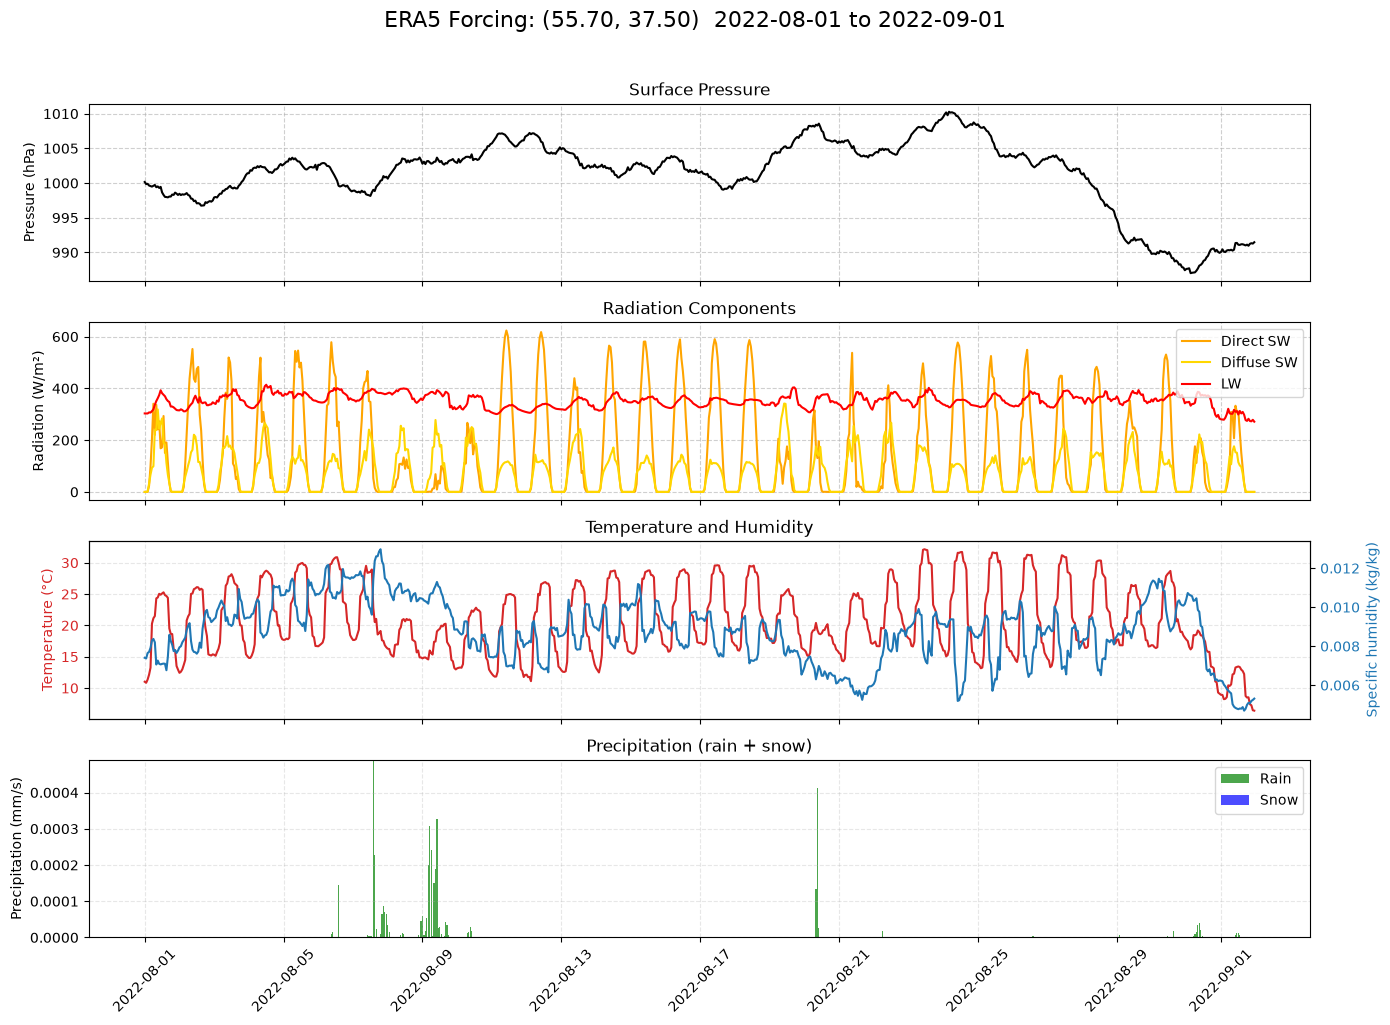

✅ Plot saved to Moscow\forcing_ERA5\era5_forcing_2022-08-01_2022-09-01.png


In [8]:
forcing_ERA5 = import_and_reload('forcing_ERA5')
os.chdir(WORK_DIR)

forcing_params = dict(lat = 55.7,
                      lon = 37.5,
                      base_dir = 'Moscow',
                      start_date = '2022-08-01',
                      end_date = '2022-09-01',
                      time = '1h')

# Set chunk_by = 'month' (or 'year') to split long periods into several requests.
# Note: that path uses xarray.open_mfdataset(parallel=True) and requires `dask` to be installed.
#forcing_params['chunk_by'] = 'month'

forcing_ERA5.prepare_forcing(**forcing_params)


## Configure and run simulations


### Configure your custom simulation based on downloaded forcing

The code cell below reads the default parameter namelist, applies modifications (e.g., urban canopy
parameters or model options), and writes a new namelist for your experiment. It also configures the
forcing namelist path and the output directory.

Site data are stored as `<work_dir>/<site_name>/`, so different sites and experiments do not overwrite
each other.


In [9]:
import f90nml

site_name = 'Moscow'
exp_name = 'CTRL'

FORCING_NML_PATH = WORK_DIR / site_name / 'forcing_ERA5' / 'namelist_forcing.nml'
PARAMS_NML_PATH = WORK_DIR / site_name / f'params_{exp_name}.nml'
OUTPUT_DIR = WORK_DIR / site_name / f'output_{exp_name}'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

params_nml = f90nml.read(str(MODEL_DIR / 'namelist' / 'namelist.nml'))
params_nml['tebparam']['teb_utc_hour'] = 3

# ***** Insert other namelist modifications here *****
# params_nml['tebparam']['...'] = ...

params_nml.write(str(PARAMS_NML_PATH), force=True)

print(f'Forcing   namelist: {FORCING_NML_PATH}')
print(f'Parameters namelist: {PARAMS_NML_PATH}')
print(f'Output directory   : {OUTPUT_DIR}')


Forcing   namelist: D:\TEB_work\Moscow\forcing_ERA5\namelist_forcing.nml
Parameters namelist: D:\TEB_work\Moscow\params_CTRL.nml
Output directory   : D:\TEB_work\Moscow\output_CTRL


### Run model for your custom simulation using command-line arguments

```
# Custom forcing namelist

TEB_offline.exe -forcing_nml my_forcing.nml

# Custom parameters namelist

TEB_offline.exe -forcing_nml my_forcing.nml -param_nml my_params.nml -output my_results/

# Custom output folder

TEB_offline.exe -output my_results/

# Help

TEB_offline.exe -help

```

The output folder must exist before the run - the model creates its files with `STATUS='NEW'`.


In [10]:
if EXE_PATH is None:
    raise RuntimeError('The model executable was not built - fix the compilation step first.')

run_utils = import_and_reload('run_utils')
run_utils.run_in_cell(exe_path=EXE_PATH,
                      args=['-forcing_nml', str(FORCING_NML_PATH),
                            '-param_nml', str(PARAMS_NML_PATH),
                            '-output', str(OUTPUT_DIR)],
                      log_file=str(OUTPUT_DIR / 'model_output.log'),
                      cwd=str(MODEL_DIR), num_lines=5)


  
     --------------------------
     |  TEB-Ru OFFLINE SIMULATION ENDS CORRECTLY |
     --------------------------
  
✅ Process finished (return code 0). Full log saved to 'D:\TEB_work\Moscow\output_CTRL\model_output.log'.


0

In [ ]:
output_utils = import_and_reload('output_utils')

output_df = output_utils.read_output(str(OUTPUT_DIR) + '/', str(FORCING_NML_PATH))
column_names = ', '.join(output_df.columns)
print(f'{len(output_df)} output time steps')
print(f'variables: {column_names}')


In [ ]:
forcing_utils = import_and_reload('forcing_utils')

try:
    forcing_df = forcing_utils.read_forcing(str(FORCING_NML_PATH))
    column_names = ', '.join(forcing_df.columns)
    print(f'{len(forcing_df)} forcing time steps')
    print(f'variables: {column_names}')
except FileNotFoundError as exc:
    forcing_df = None
    print(f'⚠️ Forcing data are not available ({exc}); the plots are generated without the forcing overlay')


### Preview simulation results

After the simulation, these cells read the output files and generate static (Matplotlib) and interactive
(Plotly) plots for quick visual inspection. The Matplotlib figure is also saved as a PNG next to the
model output.

The atmospheric forcing used by the run (`Forc_*.txt`, read with `forcing_utils.read_forcing()`) is
overlaid as **black lines** for comparison with the model results: the air temperature at the forcing
level on the *Temperatures* panel and the wind speed at the forcing level on the *Wind Speed* panel.
The forcing is defined at the height `hlev_teb` above the roof, so the wind speed ordering is expected
to be `FORC_WIND >= WIND_TOP >= U_CANYON`, and `FORC_TA` is an atmospheric (not a surface) value.


In [ ]:
fig_mpl, axes_mpl = output_utils.preview_output_mpl(output_df,
                                                    forcing_df=forcing_df,
                                                    save_path=str(OUTPUT_DIR / 'preview_output_mpl.png'))


In [ ]:
output_utils.preview_output_plotly(output_df, forcing_df=forcing_df)


## Notes and troubleshooting (Windows)

- **Kernel.** Use the `Fort (TEB-Ru)` kernel. If the environment check reports another interpreter,
  switch it in VS Code: *Select Kernel -> Python Environments -> Fort (TEB-Ru)*.
- **No installation from the notebook.** All Python modules are installed in advance
  (`conda run -n Fort pip install ...`); this notebook only checks that they can be imported.
- **Rebuilding.** The compilation cell runs `make clean` and `make all`, so the executable is always
  rebuilt from scratch, and the model directory can be any path.
- **POSIX shell for make.** `C:\msys64\usr\bin` is prepended to `PATH`, otherwise the Makefile
  constructs (`$(shell mkdir -p $(OBJDIR))`, `rm -rf`, `find`) and the compiler detection in
  `gfortran_args` (`command -v ifort`) do not work.
- **Paths with spaces.** The executable is started through an argument list (no shell), so paths such as
  `D:\My Data\TEB_work` are safe.
- **Relative paths of the model.** Every run is performed with `cwd = MODEL_DIR`, therefore the model
  reads `input/` and writes `output/` inside the repository unless `-output` is given (as in the custom
  simulation above).
- **Changing the site or the period.** Edit `forcing_params` (cell *Download atmospheric forcing*) and
  `site_name` / `exp_name` (cell *Configure your custom simulation*). Site data are stored under
  `<work_dir>\<site_name>\`.
- **Long ERA5 requests.** By default one request per period is sent. For multi-year periods set
  `chunk_by='month'` (or `'year'`) in `forcing_params`; that code path uses
  `xarray.open_mfdataset(parallel=True)` and therefore needs `dask` in the environment.
- **Colab magics.** `%rm` and `!` shell commands of the Colab version are replaced here by
  `shutil.rmtree` and `subprocess`, because those magics are not available in a local VS Code kernel.
- **CDS key.** The key is stored in `%USERPROFILE%\.cdsapirc` and is written by
  `install_utils.init_CDS()`; the notebook prompts for it only if the file does not exist.
- **`make_variables`** in the compilation cell can be used to override compiler options, e.g.
  `make_variables = ['OTHERFLAGS=-ffpe-trap=none']` to disable the strict IEEE traps of
  `gfortran_args`. Changes of compiler flags require `clean` in `make_commands`, because `make` does not
  track flag changes.
- **Model fixes required for a local (Windows) run - already applied to the sources of this
  repository.** The original sources use several variables before they are assigned; together with the
  strict IEEE traps of `gfortran_args` this aborts the run and makes the results irreproducible:
  1. `src_teb/teb_garden.F90` - `ZALB_GD`, `ZEMIS_GD`, `ZTSRAD_GD`, `ZALB_GR`, `ZEMIS_GR`, `ZTSRAD_GR`
     are initialised to `XUNDEF` before the optional garden / greenroof blocks, because they are passed
     to `URBAN_SOLAR_ABS` / `URBAN_LW_COEF` even when `LGARDEN` / `LGREENROOF` are `.FALSE.`
     (both the built-in and the external `*_EXT` operating modes are unaffected - they overwrite the
     values afterwards).
  2. `src_teb/urban_drag.F90` - the computation of `ZTS_GROUND` (used in `ZQ0`, and hence for the
     canyon wind and the road aerodynamic conductance) has been restored, with a guard against a zero
     `XROAD + XGARDEN` denominator.
  3. `src_teb/urban_snow_evol.F90` - the snow-depth outputs `PSNOWD_RF` / `PSNOWD_RD` are initialised
     to `0.` together with the other snow outputs, because they are only computed inside
     `IF (GSN_RF)` / `IF (GSN_RD)`.
  With these three fixes the test case runs to the end, produces no `NaN` and two consecutive runs give
  bit-identical output files.
